In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import numpy as np

c:\Users\jaira\anaconda3\envs\llm_pruning\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
from huggingface_hub import login
import os

In [15]:
import matplotlib.pyplot as plt

In [3]:
load_dotenv()
login(token=os.getenv("HF_TOKEN"))

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
from eval_functions import evaluate_gsm8k, score_choice, evaluate_arc, evaluate_perplexity
from wanda_pruning import evaluate_wanda_sweep
from layerwise_perturbation import layerwise_reasoning_sensitivity

In [5]:
MODEL_NAME = "meta-llama/Llama-3.2-1B"
device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float16,   
    device_map="auto"            
)

Loading weights: 100%|██████████| 146/146 [00:01<00:00, 136.01it/s]


In [7]:
model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (ro

In [8]:
results = {}
results['gsm8k'] = evaluate_gsm8k(model, tokenizer, num_samples=200)
results['arc_challenge'] = evaluate_arc(model, tokenizer, num_samples=200)
results['perplexity'] = evaluate_perplexity(model, tokenizer)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for op

GSM8K Accuracy: 0.140 (28/200)
ARC-Challenge Accuracy: 0.330 (66/200)
Perplexity (WikiText-2): 10.20


In [9]:
for k, v in results.items():
    print(f"{k}: {v}")

gsm8k: 0.14
arc_challenge: 0.33
perplexity: 10.204358282243641


In [10]:
sparsities = [0.2, 0.4, 0.6]
wanda_results = evaluate_wanda_sweep(
    AutoModelForCausalLM,
    MODEL_NAME,
    tokenizer,
    sparsities,
    evaluate_gsm8k,
    evaluate_arc,
    evaluate_perplexity,
)
for sp, metrics in wanda_results.items():
    print(sp, metrics)

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 146/146 [00:00<00:00, 429.86it/s]
Token indices sequence length is longer than the specified maximum sequence length for this model (139222 > 131072). Running this sequence through the model will result in indexing errors
wanda calib: 100%|██████████| 32/32 [00:03<00:00, 10.64it/s]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 f

GSM8K Accuracy: 0.120 (24/200)
ARC-Challenge Accuracy: 0.325 (65/200)
Perplexity (WikiText-2): 10.67


wanda calib: 100%|██████████| 32/32 [00:02<00:00, 10.76it/s]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end ge

GSM8K Accuracy: 0.085 (17/200)
ARC-Challenge Accuracy: 0.290 (58/200)
Perplexity (WikiText-2): 15.70


wanda calib: 100%|██████████| 32/32 [00:02<00:00, 10.93it/s]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end ge

GSM8K Accuracy: 0.065 (13/200)
ARC-Challenge Accuracy: 0.210 (42/200)
Perplexity (WikiText-2): 209.96
0.2 {'gsm8k': 0.12, 'arc_challenge': 0.325, 'perplexity': np.float64(10.669430185940788)}
0.4 {'gsm8k': 0.085, 'arc_challenge': 0.29, 'perplexity': np.float64(15.70383014175019)}
0.6 {'gsm8k': 0.065, 'arc_challenge': 0.21, 'perplexity': np.float64(209.96067511953197)}


In [11]:
layerwise_results = layerwise_reasoning_sensitivity(
    model,
    tokenizer,
    evaluate_gsm8k,
    num_samples=200,
    scale=0.5,
)
print("baseline", layerwise_results["baseline"])
for row in layerwise_results["per_layer"]:
    print(row)

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.140 (28/200)


layer perturb:   0%|          | 0/16 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation

GSM8K Accuracy: 0.075 (15/200)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

...

GSM8K Accuracy: 0.165 (33/200)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.120 (24/200)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

GSM8K Accuracy: 0.145 (29/200)
baseline 0.14
{'layer': 0, 'accuracy': 0.075, 'drop': 0.06500000000000002, 'sensitivity': 0.06500000000000002}
{'layer': 1, 'accuracy': 0.12, 'drop': 0.020000000000000018, 'sensitivity': 0.020000000000000018}
{'layer': 2, 'accuracy': 0.085, 'drop': 0.05500000000000001, 'sensitivity': 0.05500000000000001}
{'layer': 3, 'accuracy': 0.08, 'drop': 0.06000000000000001, 'sensitivity': 0.06000000000000001}
{'layer': 4, 'accuracy': 0.1, 'drop': 0.04000000000000001, 'sensitivity': 0.04000000000000001}
{'layer': 5, 'accuracy': 0.08, 'drop': 0.06000000000000001, 'sensitivity': 0.06000000000000001}
{'layer': 6, 'accuracy': 0.08, 'drop': 0.06000000000000001, 'sensitivity': 0.06000000000000001}
{'layer': 7, 'accuracy': 0.09, 'drop': 0.05000000000000002, 'sensitivity': 0.05000000000000002}
{'layer': 8, 'accuracy': 0.085, 'drop': 0.05500000000000001, 'sensitivity': 0.05500000000000001}
{'layer': 9, 'accuracy': 0.1, 'drop': 0.04000000000000001, 'sensitivity': 0.04000000000

In [12]:
layerwise_results

{'baseline': 0.14,
 'per_layer': [{'layer': 0,
   'accuracy': 0.075,
   'drop': 0.06500000000000002,
   'sensitivity': 0.06500000000000002},
  {'layer': 1,
   'accuracy': 0.12,
   'drop': 0.020000000000000018,
   'sensitivity': 0.020000000000000018},
  {'layer': 2,
   'accuracy': 0.085,
   'drop': 0.05500000000000001,
   'sensitivity': 0.05500000000000001},
  {'layer': 3,
   'accuracy': 0.08,
   'drop': 0.06000000000000001,
   'sensitivity': 0.06000000000000001},
  {'layer': 4,
   'accuracy': 0.1,
   'drop': 0.04000000000000001,
   'sensitivity': 0.04000000000000001},
  {'layer': 5,
   'accuracy': 0.08,
   'drop': 0.06000000000000001,
   'sensitivity': 0.06000000000000001},
  {'layer': 6,
   'accuracy': 0.08,
   'drop': 0.06000000000000001,
   'sensitivity': 0.06000000000000001},
  {'layer': 7,
   'accuracy': 0.09,
   'drop': 0.05000000000000002,
   'sensitivity': 0.05000000000000002},
  {'layer': 8,
   'accuracy': 0.085,
   'drop': 0.05500000000000001,
   'sensitivity': 0.055000000000

In [13]:
for i in layerwise_results['per_layer']:
    print(i)

{'layer': 0, 'accuracy': 0.075, 'drop': 0.06500000000000002, 'sensitivity': 0.06500000000000002}
{'layer': 1, 'accuracy': 0.12, 'drop': 0.020000000000000018, 'sensitivity': 0.020000000000000018}
{'layer': 2, 'accuracy': 0.085, 'drop': 0.05500000000000001, 'sensitivity': 0.05500000000000001}
{'layer': 3, 'accuracy': 0.08, 'drop': 0.06000000000000001, 'sensitivity': 0.06000000000000001}
{'layer': 4, 'accuracy': 0.1, 'drop': 0.04000000000000001, 'sensitivity': 0.04000000000000001}
{'layer': 5, 'accuracy': 0.08, 'drop': 0.06000000000000001, 'sensitivity': 0.06000000000000001}
{'layer': 6, 'accuracy': 0.08, 'drop': 0.06000000000000001, 'sensitivity': 0.06000000000000001}
{'layer': 7, 'accuracy': 0.09, 'drop': 0.05000000000000002, 'sensitivity': 0.05000000000000002}
{'layer': 8, 'accuracy': 0.085, 'drop': 0.05500000000000001, 'sensitivity': 0.05500000000000001}
{'layer': 9, 'accuracy': 0.1, 'drop': 0.04000000000000001, 'sensitivity': 0.04000000000000001}
{'layer': 10, 'accuracy': 0.135, 'dro

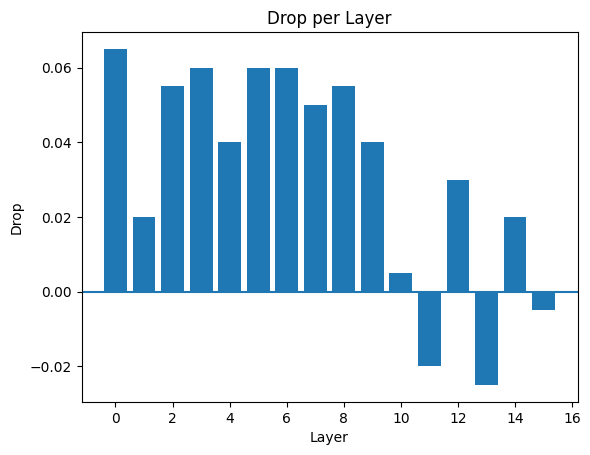

In [16]:
layers = [entry['layer'] for entry in layerwise_results['per_layer']]
drops = [entry['drop'] for entry in layerwise_results['per_layer']]

plt.figure()
plt.bar(layers, drops)

# 0 reference line
plt.axhline(0)

plt.xlabel("Layer")
plt.ylabel("Drop")
plt.title("Drop per Layer")
plt.show()